# Example 7: Ground-Station Orbit Determination for a Lunar Satellite

This notebook estimates the trajectory of a lunar satellite in an Elliptical Lunar
Frozen Orbit (ELFO) from **range and range-rate (Doppler) tracking** by three Deep
Space Network (DSN) complexes: Goldstone (`DSS14`), Canberra (`DSS43`), and Madrid
(`DSS63`).

The entire simulation -- truth propagation, visibility analysis, measurement
simulation, and the iterative batch (weighted least-squares) orbit-determination
filter -- runs in C++ via `pnt.GroundStationOdtsSimulation`
(`cpp/lupnt/simulations/GroundStationODTS/`). This notebook only configures the
simulation and visualizes its results. The batch filter itself is the shared
`lupnt::RunBatchFilter` implementation in `cpp/lupnt/filters/batch_filter.h`; the
design matrix is a numerical (finite-difference) Jacobian of the analytic
range/range-rate observation model, built by re-propagating the state with
`NBodyDynamics::Propagate`.

**Workflow:**
1. Configure the ELFO orbit, force model, DSN ground stations, and measurement noise
2. Run the simulation (truth trajectory, visibility, simulated measurements, batch filter)
3. Inspect visibility windows and simulated measurements
4. Inspect batch-filter convergence, post-fit residuals, and the formal covariance
5. Compare the recovered trajectory against truth

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import pylupnt as pnt

[00.00][PyLuPNT] Initializing


## 1. Configure the Simulation

`GroundStationOdtsConfig` bundles everything the C++ simulation needs: the ELFO
orbital elements, force model, ground-station network, simulation timing,
measurement noise, the a-priori state-error to inject into the batch filter's
starting guess, and the batch filter's own settings. Defaults already match
Example 1's ELFO and the DSN 70 m subnet (`pnt.default_dsn_stations()`); we only
override the fields we want to highlight.

In [2]:
cfg = pnt.GroundStationOdtsConfig()

# ELFO (same frozen orbit as Example 1), Moon-centered Orbital-Plane frame.
cfg.start_epoch_utc = "2026-01-01T00:00:00"
cfg.orbit_a_m = 6541.4e3
cfg.orbit_ecc = 0.6
cfg.orbit_inc_rad = 56.2 * pnt.RAD
cfg.orbit_raan_rad = 0.0
cfg.orbit_argp_rad = 90.0 * pnt.RAD
cfg.orbit_mean_anomaly_rad = 0.0

# Force model: 2x2 Moon gravity + Earth/Sun third-body + SRP (matches Example 1).
cfg.moon_gravity_degree = 2
cfg.moon_gravity_order = 2
cfg.include_earth = True
cfg.include_sun = True
cfg.use_srp = True
cfg.srp_cr, cfg.srp_area_m2, cfg.srp_mass_kg = 1.8, 0.02, 10.0

# DSN 70 m ground stations (Goldstone / Canberra / Madrid) and visibility.
cfg.ground_stations = pnt.default_dsn_stations()
cfg.elevation_mask_deg = 10.0

# Simulation timing: 36 hours (~2.7 orbits) at a 5-minute observation cadence.
cfg.duration_s = 36.0 * 3600.0
cfg.obs_interval_s = 300.0

# Measurement noise (representative DSN coherent ranging/Doppler precision).
cfg.use_range = True
cfg.use_range_rate = True
cfg.range_sigma_m = 10.0
cfg.range_rate_sigma_mps = 1.0e-3

# Deliberately poor a-priori state (~km-level position, ~0.5 m/s velocity error),
# sampled ~ N(0, sigma^2) and seeded by cfg.seed for reproducibility.
cfg.initial_position_sigma_m = 2000.0
cfg.initial_velocity_sigma_mps = 0.5
cfg.seed = 42

# Batch (iterative weighted-least-squares) filter.
cfg.batch_max_iterations = 10
cfg.batch_convergence_tol = 1.0e-3
cfg.batch_use_initialization = False

for lla in cfg.ground_stations:
    print(f"{lla.name:20s}  lat={lla.latitude_deg:7.3f}  lon={lla.longitude_deg:7.3f}  "
          f"alt={lla.altitude_m:6.1f} m")

DSS14 (Goldstone)     lat= 35.426  lon=243.110  alt=1001.4 m
DSS43 (Canberra)      lat=-35.402  lon=148.981  alt= 688.9 m
DSS63 (Madrid)        lat= 40.431  lon=355.752  alt= 864.8 m


## 2. Run the Simulation

`run()` cascades through `setup() -> precompute() -> run()` automatically: it builds
the truth trajectory and dynamics, runs the visibility analysis, simulates noisy
range/range-rate measurements, and then hands them to `lupnt::RunBatchFilter`.

In [3]:
sim = pnt.GroundStationOdtsSimulation(cfg)
sim.run()
results = sim.get_results()

t_hrs = (results.t_tdb - results.t_tdb[0]) / pnt.SECS_HOUR
station_colors = {"DSS14 (Goldstone)": "steelblue", "DSS43 (Canberra)": "darkorange",
                  "DSS63 (Madrid)": "seagreen"}

print(f"Epochs: {len(results.t_tdb)}   Measurements: {len(results.obs_epoch_index)}")
print(f"Converged: {results.converged}   Iterations: {results.num_iterations}")

Epochs: 433   Measurements: 629
Converged: True   Iterations: 7


## 3. Visibility Analysis

`results.elevation_deg` is the topocentric elevation of the satellite as seen from
each station, evaluated on the full simulation grid; the 10&deg; mask used to select
tracking measurements is overlaid.

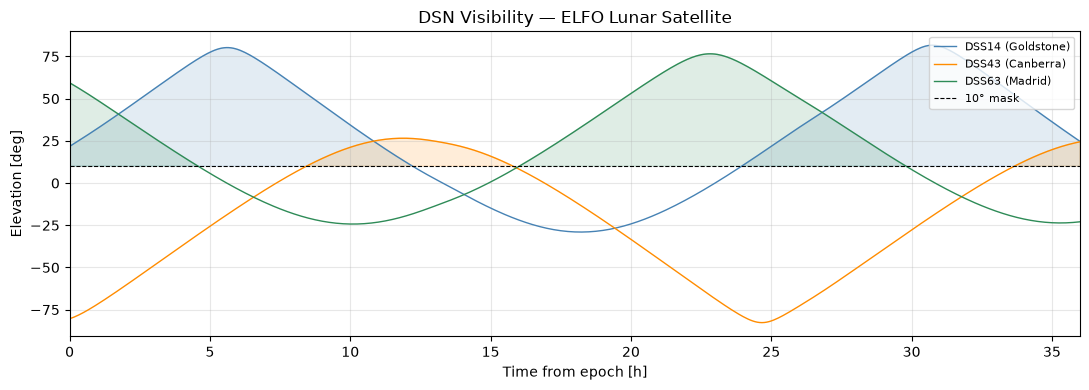

DSS14 (Goldstone)      292/433 epochs visible ( 67.4%)
DSS43 (Canberra)       117/433 epochs visible ( 27.0%)
DSS63 (Madrid)         220/433 epochs visible ( 50.8%)


In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
for j, name in enumerate(results.station_names):
    el = results.elevation_deg[:, j]
    vis = el > cfg.elevation_mask_deg
    color = station_colors.get(name, f"C{j}")
    ax.plot(t_hrs, el, lw=1.0, color=color, label=name)
    ax.fill_between(t_hrs, el, cfg.elevation_mask_deg, where=vis, color=color, alpha=0.15)
ax.axhline(cfg.elevation_mask_deg, color="k", ls="--", lw=0.8,
           label=f"{cfg.elevation_mask_deg:.0f}\N{DEGREE SIGN} mask")
ax.set_xlabel("Time from epoch [h]")
ax.set_ylabel("Elevation [deg]")
ax.set_title("DSN Visibility — ELFO Lunar Satellite")
ax.set_xlim(0, t_hrs[-1])
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for j, name in enumerate(results.station_names):
    n_vis = int(np.sum(results.elevation_deg[:, j] > cfg.elevation_mask_deg))
    print(f"{name:20s}  {n_vis:4d}/{len(t_hrs)} epochs visible "
          f"({100 * n_vis / len(t_hrs):5.1f}%)")

## 4. Simulated Range and Range-Rate Measurements

Each measurement is tagged with an epoch index (into `results.t_tdb`) and a station
index (into `results.station_names`).

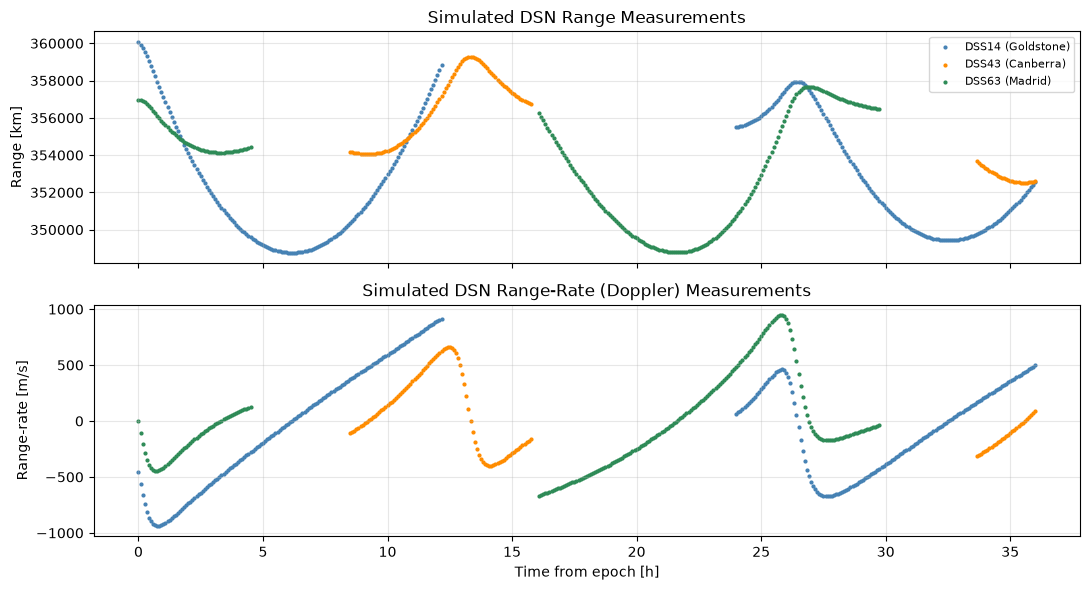

In [5]:
obs_t_hrs = t_hrs[results.obs_epoch_index]
obs_station_names = [results.station_names[s] for s in results.obs_station_index]

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for name in results.station_names:
    mask = [s == name for s in obs_station_names]
    color = station_colors.get(name, "gray")
    axes[0].scatter(obs_t_hrs[mask], results.obs_range_m[mask] / 1e3, s=4, color=color, label=name)
    axes[1].scatter(obs_t_hrs[mask], results.obs_range_rate_mps[mask], s=4, color=color)

axes[0].set_ylabel("Range [km]")
axes[0].set_title("Simulated DSN Range Measurements")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[1].set_ylabel("Range-rate [m/s]")
axes[1].set_xlabel("Time from epoch [h]")
axes[1].set_title("Simulated DSN Range-Rate (Doppler) Measurements")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Batch Filter Convergence

`results.iteration_*` arrays record one entry per batch-filter iteration (from
`BatchFilterResults::iteration_history` in `lupnt/filters/batch_filter.h`):
the state estimate at the *start* of the iteration, the correction norm applied,
the weighted RMS residual (dimensionless, normalized by each measurement's own
noise sigma), and -- computed here from the logged state -- position/velocity
error against truth and per-measurement-type RMS residuals.

In [6]:
pos0 = np.linalg.norm(results.x0_initial_guess[:3] - results.x0_true[:3])
vel0 = np.linalg.norm(results.x0_initial_guess[3:] - results.x0_true[3:])
print(f"Initial position error: {pos0:.1f} m   Initial velocity error: {vel0:.3f} m/s")
print()
for k in range(results.num_iterations):
    print(f"iter {k}: rms(rho)={results.iteration_rms_range_m[k]:8.3f} m  "
          f"rms(rho_dot)={results.iteration_rms_range_rate_mps[k]:9.6f} m/s  "
          f"|pos_err|={results.iteration_pos_error_m[k]:9.3f} m  "
          f"|vel_err|={results.iteration_vel_error_mps[k]:9.6f} m/s  "
          f"weighted_rms={results.iteration_weighted_rms[k]:8.3f}")

Initial position error: 2010.7 m   Initial velocity error: 1.282 m/s

iter 0: rms(rho)=163243.557 m  rms(rho_dot)=39.513663 m/s  |pos_err|= 2010.679 m  |vel_err|= 1.281605 m/s  weighted_rms=30230.896
iter 1: rms(rho)=25113.380 m  rms(rho_dot)= 4.063462 m/s  |pos_err|=36447.898 m  |vel_err|=20.989224 m/s  weighted_rms=3377.761
iter 2: rms(rho)=8541.689 m  rms(rho_dot)= 2.055287 m/s  |pos_err|=  639.435 m  |vel_err|= 0.471980 m/s  weighted_rms=1573.818
iter 3: rms(rho)=  72.784 m  rms(rho_dot)= 0.006673 m/s  |pos_err|=   95.876 m  |vel_err|= 0.060162 m/s  weighted_rms=   6.982
iter 4: rms(rho)=  10.106 m  rms(rho_dot)= 0.001016 m/s  |pos_err|=    1.150 m  |vel_err|= 0.001351 m/s  weighted_rms=   1.013
iter 5: rms(rho)=  10.053 m  rms(rho_dot)= 0.001012 m/s  |pos_err|=    0.634 m  |vel_err|= 0.000677 m/s  weighted_rms=   1.009
iter 6: rms(rho)=  10.053 m  rms(rho_dot)= 0.001012 m/s  |pos_err|=    0.643 m  |vel_err|= 0.000669 m/s  weighted_rms=   1.009


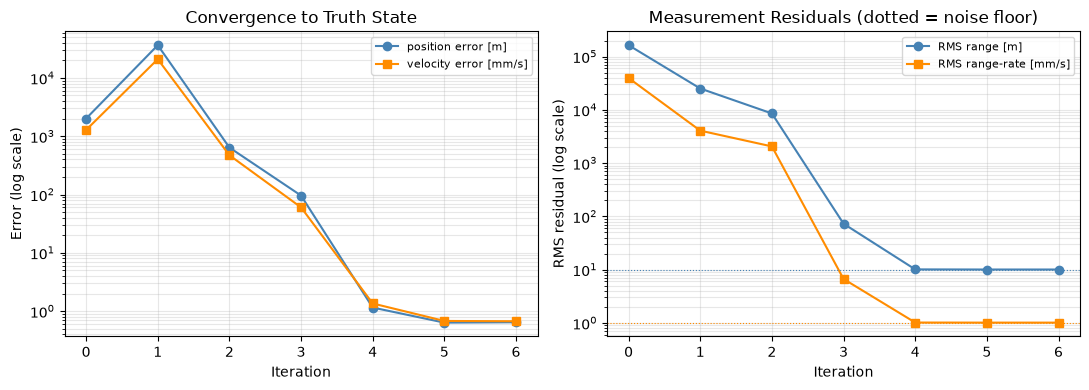

In [7]:
iters = np.arange(results.num_iterations)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].semilogy(iters, results.iteration_pos_error_m, "o-", color="steelblue",
                  label="position error [m]")
axes[0].semilogy(iters, results.iteration_vel_error_mps * 1e3, "s-", color="darkorange",
                  label="velocity error [mm/s]")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Error (log scale)")
axes[0].set_title("Convergence to Truth State")
axes[0].legend(fontsize=8)
axes[0].grid(True, which="both", alpha=0.3)

axes[1].semilogy(iters, results.iteration_rms_range_m, "o-", color="steelblue",
                  label="RMS range [m]")
axes[1].semilogy(iters, results.iteration_rms_range_rate_mps * 1e3, "s-", color="darkorange",
                  label="RMS range-rate [mm/s]")
axes[1].axhline(cfg.range_sigma_m, color="steelblue", ls=":", lw=0.8)
axes[1].axhline(cfg.range_rate_sigma_mps * 1e3, color="darkorange", ls=":", lw=0.8)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("RMS residual (log scale)")
axes[1].set_title("Measurement Residuals (dotted = noise floor)")
axes[1].legend(fontsize=8)
axes[1].grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Final Solution and Formal Covariance

In [8]:
sigma = np.sqrt(np.diag(results.covariance))

print("Estimated epoch state (MCI frame):")
print(f"  r0 = {results.x0_estimated[:3]} m")
print(f"  v0 = {results.x0_estimated[3:]} m/s")
print()

pos_err = np.linalg.norm(results.x0_estimated[:3] - results.x0_true[:3])
vel_err = np.linalg.norm(results.x0_estimated[3:] - results.x0_true[3:])
print(f"Final position error vs. truth: {pos_err:.3f} m "
      f"(formal 1-sigma: {np.linalg.norm(sigma[:3]):.3f} m)")
print(f"Final velocity error vs. truth: {vel_err:.6f} m/s "
      f"(formal 1-sigma: {np.linalg.norm(sigma[3:]):.6f} m/s)")

Estimated epoch state (MCI frame):
  r0 = [ 410803.761402    178481.36606556 2577939.25618233] m
  v0 = [-1636.08730588   520.33116742   224.69216142] m/s

Final position error vs. truth: 0.643 m (formal 1-sigma: 1.870 m)
Final velocity error vs. truth: 0.000669 m/s (formal 1-sigma: 0.000969 m/s)


## 7. Estimated vs. Truth Trajectory

`results.truth_state` and `results.estimated_state` are both propagated over the
same time grid in the Moon-Centered Inertial (MCI) frame, ready to overlay
directly.

In [9]:
fig = go.Figure()
pnt.plot.plot_body(fig, pnt.MOON)
pnt.plot.plot_orbits(fig, np.stack([results.truth_state, results.estimated_state]), t=0,
                     color=["steelblue", "crimson"])
pnt.plot.set_view(fig, azimuth=-35, elevation=10, zoom=3)
fig.update_layout(
    width=560, height=560,
    title="Truth (blue) vs. Batch-Filter Estimate (red) — MCI frame",
)
fig.show()

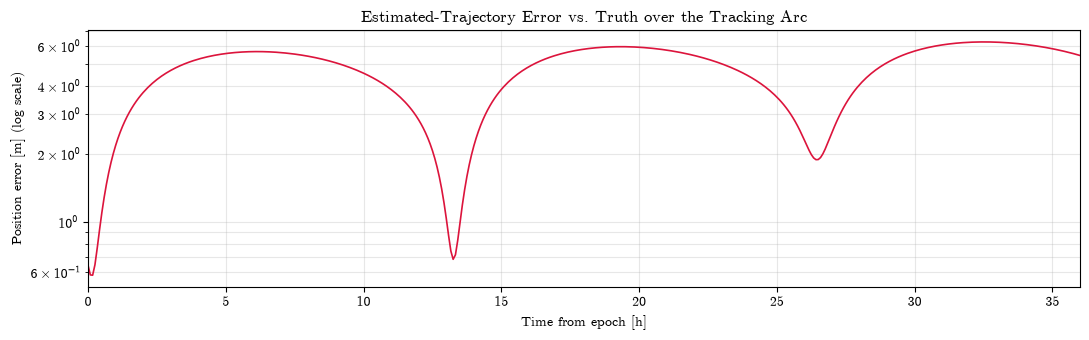

Max position error over 36 h arc: 6.27 m


In [10]:
pos_err_t = np.linalg.norm(results.estimated_state[:, :3] - results.truth_state[:, :3], axis=1)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.semilogy(t_hrs, pos_err_t, color="crimson", lw=1.2)
ax.set_xlabel("Time from epoch [h]")
ax.set_ylabel("Position error [m] (log scale)")
ax.set_title("Estimated-Trajectory Error vs. Truth over the Tracking Arc")
ax.set_xlim(0, t_hrs[-1])
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Max position error over {cfg.duration_s / pnt.SECS_HOUR:.0f} h arc: {pos_err_t.max():.2f} m")